# Import Libraries

Importing all required Python dependencies such as TensorFlow, Keras, scikit-learn, and visualization tools necessary for data processing and model building.

In [ ]:
import os
import gdown
import random
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

!pip install split-folders -q
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, accuracy_score

!pip install tensorflowjs -q 2> /dev/null
import shutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 91.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Data Preparation

Acquiring and understanding the raw dataset before any transformations are applied.


## Data Loading

Downloading the dataset archive from Google Drive and extracting its contents into the local environment.

In [ ]:
FILE_ID = '1aGGi0Gh1Ho3GuRD-U2AxyOuOkxoTVwrZ'
ZIP_NAME = 'garbage-dataset.zip'
DATASET_PATH = 'garbage-dataset'

url = f'https://drive.google.com/uc?id={FILE_ID}'

if os.path.exists(DATASET_PATH):
    pass
else:
    if not os.path.exists(ZIP_NAME):
        gdown.download(url, ZIP_NAME, quiet=False)
    !unzip -q {ZIP_NAME} -d {DATASET_PATH}

Downloading...
From (original): https://drive.google.com/uc?id=1aGGi0Gh1Ho3GuRD-U2AxyOuOkxoTVwrZ
From (redirected): https://drive.google.com/uc?id=1aGGi0Gh1Ho3GuRD-U2AxyOuOkxoTVwrZ&confirm=t&uuid=08888efb-d78b-4559-b358-10088292fbcc
To: /content/garbage-dataset.zip
100%|██████████| 520M/520M [00:11<00:00, 44.5MB/s]


## Directory Structure Exploration

Iterating through the extracted folders to count the total number of images available per class.

In [ ]:
total_images = 0
class_counts = {}

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        num_files = len(files)

        class_counts[class_name] = num_files
        total_images += num_files

        print(f"- Class '{class_name}': {num_files} files")
print(f"\nTOTAL FILES: {total_images}")

- Class 'battery': 756 files
- Class 'biological': 699 files
- Class 'cardboard': 1411 files
- Class 'clothes': 1892 files
- Class 'glass': 1736 files
- Class 'metal': 930 files
- Class 'paper': 1336 files
- Class 'plastic': 1597 files
- Class 'shoes': 1449 files
- Class 'trash': 453 files

TOTAL FILES: 12259


## Image Distribution

Visualizing the quantity of images across all 10 waste categories using a bar chart to identify any class imbalances.

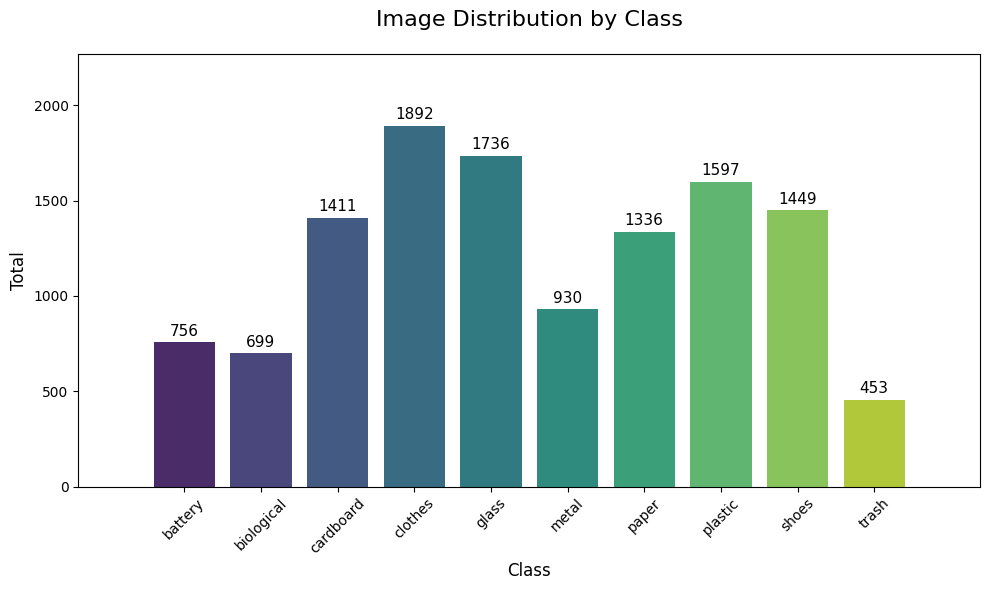

In [ ]:
class_names = []
image_counts = []

for item_name in sorted(os.listdir(DATASET_PATH)):
  item_path = os.path.join(DATASET_PATH, item_name)
  if os.path.isdir(item_path):
    count = len(os.listdir(item_path))
    class_names.append(item_name)
    image_counts.append(count)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_names, y=image_counts, palette="viridis")

plt.title('Image Distribution by Class', fontsize=16, pad=20)
plt.subplots_adjust(top=10)
plt.margins(x=0.1, y=0.2)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Total', fontsize=12)
plt.xticks(rotation=45)

for i, count in enumerate(image_counts):
  ax.text(i, count + 20, str(count), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## Image Resolution

Analyzing the varied dimensions of the original images to determine the optimal target size for the neural network input.

File: paper/paper_175.jpg | Original Resolution: 533 x 355 pixel
File: trash/trash_15.jpg | Original Resolution: 225 x 225 pixel
File: shoes/shoes_1366.jpg | Original Resolution: 225 x 225 pixel
File: plastic/plastic_932.jpg | Original Resolution: 768 x 1024 pixel


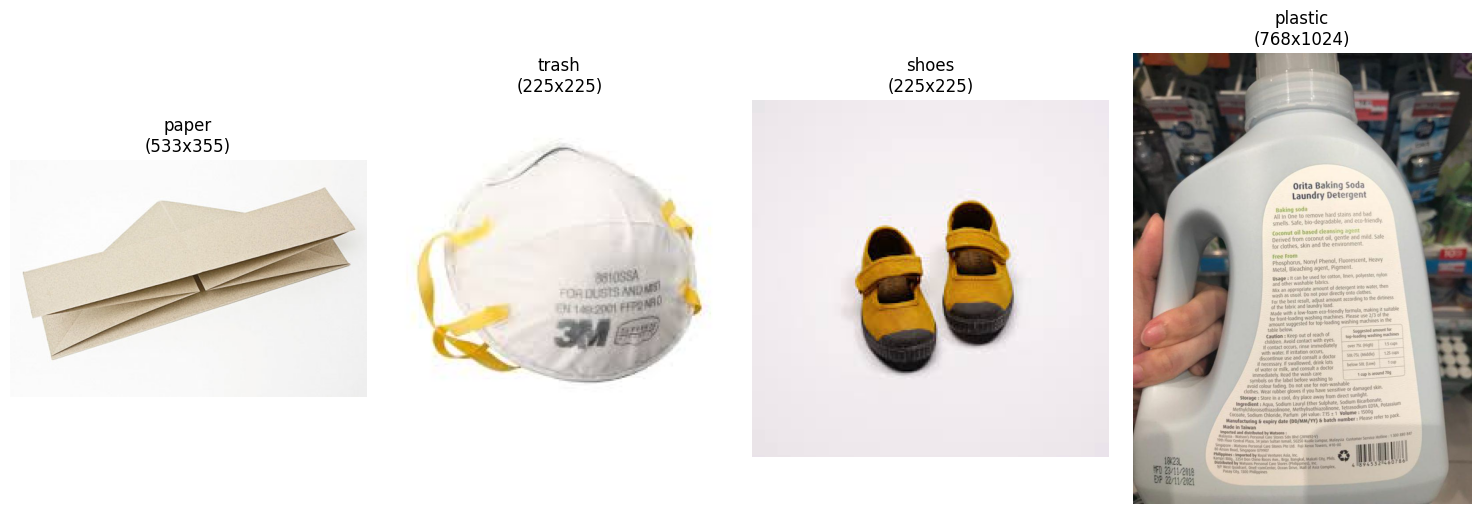

In [ ]:
classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
sample_classes = random.sample(classes, 4)
plt.figure(figsize=(15, 5))

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(DATASET_PATH, class_name)

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)

    img = Image.open(img_path)
    width, height = img.size

    print(f"File: {class_name}/{random_image_name} | Original Resolution: {width} x {height} pixel")

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(f"{class_name}\n({width}x{height})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Data Preprocessing

Preparing and augmenting the image data so the model can learn robust patterns effectively.

## Image Data Generator Configuration

Configuring dynamic image augmentations such as rotation, zoom, and shifts to artificially expand the dataset and prevent overfitting.

In [ ]:
INPUT_DATA_DIR = DATASET_PATH
SPLIT_DATA_DIR = os.path.join(DATASET_PATH, 'split_data')

if not os.path.exists(SPLIT_DATA_DIR):
    splitfolders.ratio(
        INPUT_DATA_DIR,
        output=SPLIT_DATA_DIR,
        seed=42,
        ratio=(0.8, 0.1, 0.1),
        group_prefix=None,
        move=False
    )
else:
    print(f"Folder split is already exist: {SPLIT_DATA_DIR}\n")

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()

Copying files: 12259 files [00:04, 2699.39 files/s]


## Creating Train, Validation, and Test Generators

Splitting the data directories into three distinct subsets and generating flowing batches of resized images.

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 9802 images belonging to 10 classes.
Found 1221 images belonging to 10 classes.
Found 1236 images belonging to 10 classes.


## Class Imbalance Handling

Calculating class weights to penalize the model more heavily for misclassifying minority classes, ensuring fair learning across all categories.

In [ ]:
train_classes = train_generator.classes

unique_classes = np.unique(train_classes)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_classes
)

class_weight_dict = dict(enumerate(class_weights_array))

class_names = list(train_generator.class_indices.keys())

for class_index, weight in class_weight_dict.items():
    class_name = class_names[class_index]
    print(f"- {class_name.ljust(12)} (index {class_index}) : {weight:.4f}")

- battery      (index 0) : 1.6228
- biological   (index 1) : 1.7535
- cardboard    (index 2) : 0.8690
- clothes      (index 3) : 0.6479
- glass        (index 4) : 0.7062
- metal        (index 5) : 1.3175
- paper        (index 6) : 0.9178
- plastic      (index 7) : 0.7676
- shoes        (index 8) : 0.8457
- trash        (index 9) : 2.7077


# Model Architecture

Constructing the convolutional neural network that will be trained on the garbage images.

## Base Model

Initializing the pre-trained EfficientNetV2B0 model without its top classification layers to leverage its powerful feature extraction capabilities.

In [ ]:
INPUT_SHAPE = (224, 224, 3)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Sequential & Summary Model

Stacking the base model with a GlobalAveragePooling layer, Dropout for regularization, and a dense output layer with softmax activation for our 10 classes.

In [ ]:
num_classes = len(train_generator.class_indices)

model = Sequential([
    base_model,

    Conv2D(64, (3, 3), activation='relu', padding='same'),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,085,978 (27.03 MB)

 Trainable params: 1,166,666 (4.45 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

# Model Training

Teaching the neural network to recognize garbage categories through multiple phased learning stages.

## Transfer Learning

Training only the custom top layers while freezing the base model's weights to quickly adapt the network to the new classification task.

In [ ]:
loss_function = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=loss_function,
    metrics=['accuracy']
)

callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_p1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1
)

Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.5979 - loss: 1.5720
Epoch 1: val_accuracy improved from None to 0.89844, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 225s 616ms/step - accuracy: 0.7457 - loss: 1.2157 - val_accuracy: 0.8984 - val_loss: 0.8066
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8653 - loss: 0.9377
Epoch 2: val_accuracy improved from 0.89844 to 0.91155, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 152s 494ms/step - accuracy: 0.8718 - loss: 0.9277 - val_accuracy: 0.9115 - val_loss: 0.7811
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8878 - loss: 0.8881
Epoch 3: val_accuracy improved from 0.91155 to 0.93530, saving model to best_model_phase1.keras

Epoch 3: finished saving model to best_model_phase1.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 153

## Fine-Tuning

Unfreezing the top layers of the base model and training with a very low learning rate to gently adjust the pre-trained weights to our specific dataset.

In [ ]:
model = tf.keras.models.load_model('best_model_phase1.keras')

base_model = model.layers[0]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_function,
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_p2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_p2
)

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.8634 - loss: 0.9228
Epoch 1: val_accuracy improved from None to 0.91646, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 216s 603ms/step - accuracy: 0.8806 - loss: 0.8838 - val_accuracy: 0.9165 - val_loss: 0.7710
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9116 - loss: 0.8087
Epoch 2: val_accuracy improved from 0.91646 to 0.92793, saving model to best_model_finetuned.keras

Epoch 2: finished saving model to best_model_finetuned.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 155s 505ms/step - accuracy: 0.9146 - loss: 0.7946 - val_accuracy: 0.9279 - val_loss: 0.7508
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9215 - loss: 0.7777
Epoch 3: val_accuracy improved from 0.92793 to 0.92957, saving model to best_model_finetuned.keras

Epoch 3: finished saving model to best_model_finetuned.keras
307/307 ━━━━━━

## Training Metrics Visualization

Plotting the accuracy and loss curves for both training and validation sets to monitor learning progress and diagnose overfitting.

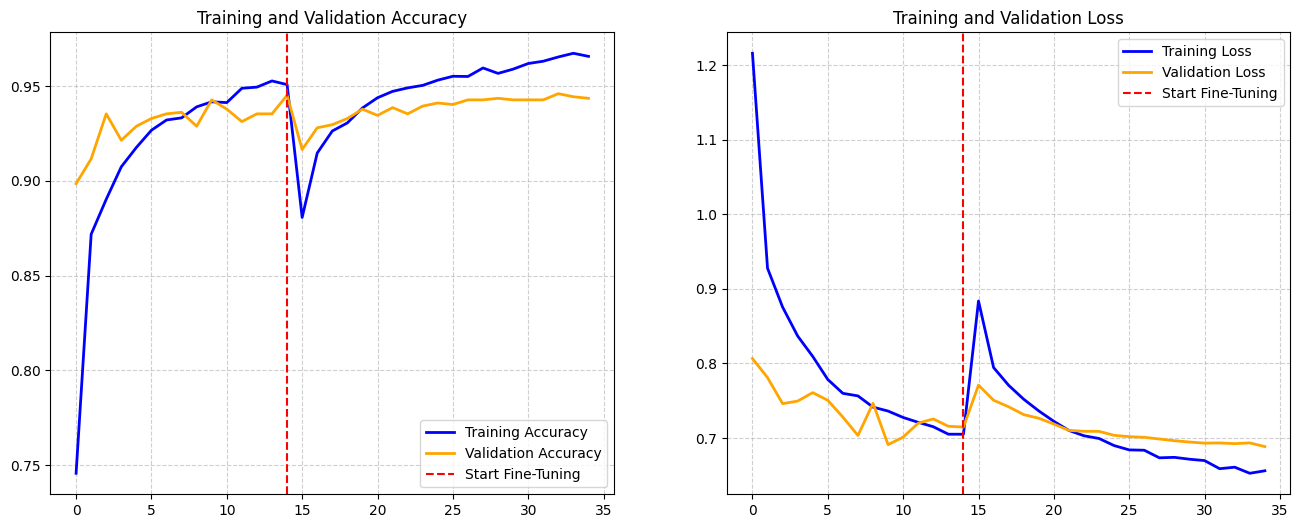

In [ ]:
acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)

plt.axvline(x=len(history_p1.history['accuracy'])-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.axvline(x=len(history_p1.history['loss'])-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## Deepest Fine-Tuning

Unfreezing the entire base model architecture to squeeze out maximum accuracy through deep, slow, and careful training iterations.

In [ ]:
model = tf.keras.models.load_model('best_model_finetuned.keras')

base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = True

loss_function = CategoricalCrossentropy(label_smoothing=0.1)
model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss=loss_function,
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

callbacks_p3 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase3.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    lr_scheduler
]

history_p3 = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_p3
)

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.7981 - loss: 1.0778
Epoch 1: val_accuracy improved from None to 0.86486, saving model to best_model_phase3.keras

Epoch 1: finished saving model to best_model_phase3.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 298s 706ms/step - accuracy: 0.7942 - loss: 1.0730 - val_accuracy: 0.8649 - val_loss: 0.9620 - learning_rate: 1.0000e-06
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.7948 - loss: 1.0611
Epoch 2: val_accuracy improved from 0.86486 to 0.86650, saving model to best_model_phase3.keras

Epoch 2: finished saving model to best_model_phase3.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 161s 524ms/step - accuracy: 0.7961 - loss: 1.0549 - val_accuracy: 0.8665 - val_loss: 0.9311 - learning_rate: 1.0000e-06
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.8059 - loss: 1.0304
Epoch 3: val_accuracy improved from 0.86650 to 0.87305, saving model to best_model_phase3.keras

Epoch 3: finished saving model to 

# Model Evaluation

Testing the trained model's performance on unseen data to measure its true generalization capabilities.

## Evaluation on Test Data

Running the initial fine-tuned model against the segregated test dataset to obtain baseline accuracy and loss metrics.

In [ ]:
final_model = tf.keras.models.load_model('best_model_finetuned.keras')

test_generator.reset()

test_loss, test_accuracy = final_model.evaluate(test_generator, verbose=1)

print(f"Accuration on Test Set: {test_accuracy * 100:.2f}%")
print(f"Loss Test Set: {test_loss:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 342ms/step - accuracy: 0.9409 - loss: 0.6926
Accuration on Test Set: 94.09%
Loss Test Set: 0.6926


## Evaluation on Test Data from Deepest Fine-Tuning

Re-evaluating the fully unfreezed model on the test dataset to verify if the deepest fine-tuning stage provided significant performance gains.

In [ ]:
final_model_v3 = tf.keras.models.load_model('best_model_phase3.keras')

test_generator.reset()

test_loss_v3, test_accuracy_v3 = final_model_v3.evaluate(test_generator, verbose=1)

print(f"\nAccuration on Test Set from Deepest Fine-Tuning: {test_accuracy_v3 * 100:.2f}%")

39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.8972 - loss: 0.7941

Accuration on Test Set from Deepest Fine-Tuning: 89.72%


## Detailed Classification Report

Generating a detailed metric report including precision, recall, and f1-score to analyze exactly which waste classes the model struggles with.

In [ ]:
y_true = test_generator.classes

test_generator.reset()
predictions = final_model.predict(test_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)

class_names = list(test_generator.class_indices.keys())

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step
              precision    recall  f1-score   support

     battery       0.99      0.97      0.98        77
  biological       1.00      0.96      0.98        71
   cardboard       0.96      0.95      0.96       142
     clothes       0.99      0.99      0.99       190
       glass       0.94      0.91      0.92       175
       metal       0.82      0.96      0.88        93
       paper       0.95      0.91      0.93       135
     plastic       0.88      0.90      0.89       161
       shoes       0.99      0.99      0.99       146
       trash       0.82      0.78      0.80        46

    accuracy                           0.94      1236
   macro avg       0.93      0.93      0.93      1236
weighted avg       0.94      0.94      0.94      1236



## Test-Time Augmentation (TTA)

Applying augmentations during the evaluation phase to make predictions on multiple variations of the same test image, further boosting the final accuracy.

In [ ]:
tta_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

tta_generator = tta_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

tta_steps = 5
predictions_tta = np.zeros((tta_generator.samples, num_classes))

for i in range(tta_steps):
    print(f"TTA iteration {i+1}/{tta_steps}...")
    tta_generator.reset()
    preds = final_model.predict(tta_generator, verbose=1)
    predictions_tta += preds

predictions_tta /= tta_steps

y_pred_tta = np.argmax(predictions_tta, axis=1)
y_true = tta_generator.classes

tta_accuracy = accuracy_score(y_true, y_pred_tta)

print(f"Accuration with TTA: {tta_accuracy * 100:.2f}%")

class_names = list(tta_generator.class_indices.keys())

print(classification_report(y_true, y_pred_tta, target_names=class_names))

Found 1236 images belonging to 10 classes.
TTA iteration 1/5...
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 444ms/step
TTA iteration 2/5...
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 472ms/step
TTA iteration 3/5...
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 450ms/step
TTA iteration 4/5...
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step
TTA iteration 5/5...
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 439ms/step
Accuration with TTA: 94.50%
              precision    recall  f1-score   support

     battery       0.96      0.97      0.97        77
  biological       1.00      1.00      1.00        71
   cardboard       0.96      0.96      0.96       142
     clothes       0.99      0.99      0.99       190
       glass       0.95      0.91      0.93       175
       metal       0.86      0.94      0.90        93
       paper       0.96      0.88      0.92       135
     plastic       0.86      0.91      0.89       161
       shoes       1.00      0.99      0.99       146
       trash       0.83      0.85      0.84        46

    accuracy      

# Model Export & Deployment Preparation

Packaging the finalized model into various optimized formats for cross-platform integration.

In [ ]:
EXPORT_DIR = 'exported_models'
if not os.path.exists(EXPORT_DIR):
    os.makedirs(EXPORT_DIR)

model_path = 'best_model_finetuned.keras'
final_model = tf.keras.models.load_model(model_path)

## Saving in SavedModel Format

Exporting the complete Keras model into TensorFlow's standard SavedModel directory structure for robust backend API deployment.

In [ ]:
saved_model_dir = os.path.join(EXPORT_DIR, 'saved_model')
final_model.export(saved_model_dir)

Saved artifact at 'exported_models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136451306613136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136451306609488: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136451657055312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306611984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306613712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306611024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306616208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306616784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306610832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306618704: TensorSpec(shape=(), dtype=tf.resour

## Converting to TF-Lite Format

Converting and compressing the model into a lightweight .tflite file optimized for mobile and edge devices.

In [ ]:
tflite_path = os.path.join(EXPORT_DIR, 'model.tflite')

converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpp2nq3_yv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136451306613136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136451306609488: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136451657055312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306611984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306613712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306611024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306616208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306616784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306610832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136451306618704: TensorSpec(shape=(), dtype=tf.resource, name=No

## Converting to TFJS Format

Translating the model into TensorFlow.js format so it can be executed directly within web browsers on the client side.

In [ ]:
tfjs_dir = os.path.join(EXPORT_DIR, 'tfjs_model')
os.system(f'tensorflowjs_converter --input_format=keras {model_path} {tfjs_dir}')

256

# Inference

Loading the converted TFLite model to perform a mock prediction on a single image, validating that the exported model functions correctly.

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


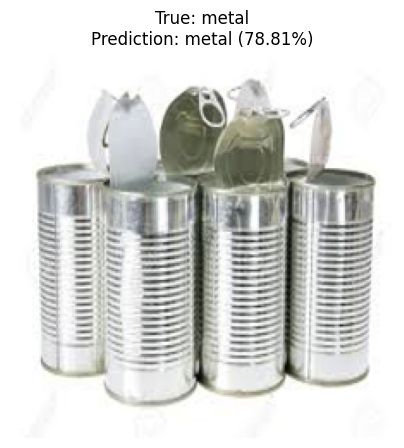

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

class_names = list(test_generator.class_indices.keys())
true_class = random.choice(class_names)
random_img_name = random.choice(os.listdir(os.path.join(TEST_DIR, true_class)))
img_path_test = os.path.join(TEST_DIR, true_class, random_img_name)

img = Image.open(img_path_test).resize((224, 224))
img_array = np.array(img, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

pred_class_index = np.argmax(output_data)
pred_class = class_names[pred_class_index]
confidence = output_data[0][pred_class_index] * 100

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"True: {true_class}\nPrediction: {pred_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()
